# Module 3 Practical Assignment
## Customer Feedback Sentiment Analysis Using Embedding + LSTM

**Trainee Name:** Naol Melaku Ayana  
**Project:** Customer Feedback Sentiment Analysis  
**Course:** FUSE-AI-201 — AI Model Development and Implementation

# Question 1 – Understanding the Problem and the Data

## Purpose of the Project
This project builds a deep learning model that reads customer feedback and classifies it as **positive** or **negative**. Banks receive thousands of comments daily, and manually sorting them is not practical. A model that can automatically detect sentiment helps teams respond faster to unhappy customers and track overall satisfaction.

## Type of Data
Text data. Each input is a short customer comment.

## Input and Target
- **Input:** the `feedback` column — one example looks like *"The staff were friendly and helped me quickly."*
- **Target:** the `sentiment` column — two classes: `positive` or `negative`.

## Exploring the Dataset
The next cells load the data and check its shape, class balance, and a few sample rows.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("customer_feedback_sentiment_large_dataset (1).csv")

# Shape and columns
print("Shape:", data.shape)
print("Columns:", data.columns.tolist())

# Check missing values
print("\nMissing values:")
print(data.isnull().sum())

# Class distribution
print("\nClass distribution:")
print(data["sentiment"].value_counts())

# Sample rows
print("\nSample rows:")
data.head()

Shape: (3200, 2)
Columns: ['feedback', 'sentiment']

Missing values:
feedback     0
sentiment    0
dtype: int64

Class distribution:
sentiment
positive    1600
negative    1600
Name: count, dtype: int64

Sample rows:


,feedback,sentiment
0,The staff were friendly and helped me quickly.,positive
1,The digital payment platform is easy to use an...,positive
2,I trust the bank because the branch service is...,positive
3,The staff were inefficient and did not help me.,negative
4,The ATM system is easy to use and very reliable.,positive


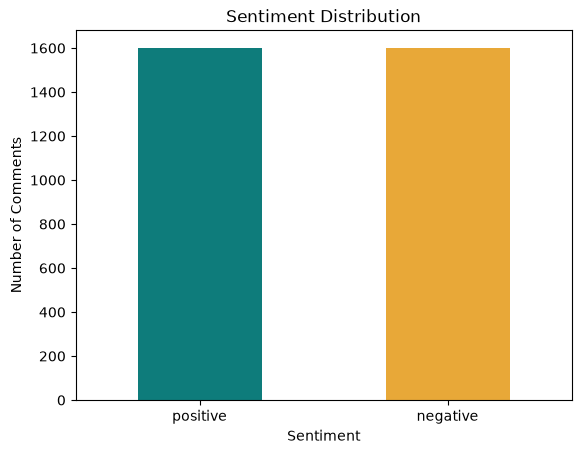

In [18]:
data["sentiment"].value_counts().plot(kind="bar", color=["#0E7C7B", "#E8A838"])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)
plt.show()

# Question 2 – Data Preparation for Deep Learning

Neural networks cannot work with raw text. They need numbers, and they need inputs of the same length. This section handles both.

## Steps
1. **Clean the text** — lowercase, remove punctuation and numbers, strip extra spaces.  
   *Why:* "Friendly" and "friendly" should count as the same word. Punctuation adds no meaning to the model.
2. **Encode the labels** — convert `positive`/`negative` into 1/0.  
   *Why:* Keras loss functions expect numeric labels, not strings.
3. **Split into train and test** — 80% training, 20% testing, stratified.  
   *Why:* We need unseen data to check whether the model actually learned.
4. **Tokenize** — turn each word into an integer ID using a vocabulary of the 5,000 most common words.  
   *Why:* The embedding layer needs integer indices.
5. **Pad sequences** — every comment becomes exactly 30 tokens long.  
   *Why:* Keras trains on fixed-size batches; variable-length inputs break that.

In [19]:
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

data["clean_feedback"] = data["feedback"].apply(clean_text)

# Encode labels
label_encoder = LabelEncoder()
data["sentiment_encoded"] = label_encoder.fit_transform(data["sentiment"])
print("Classes:", label_encoder.classes_)

# Separate features and target
X_text = data["clean_feedback"]
y = data["sentiment_encoded"]

# Train/test split (80/20, stratified)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

Classes: ['negative' 'positive']
Train size: 2560
Test size: 640


In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenizer settings
vocab_size = 5000
oov_token = "<OOV>"
max_length = 30

# Build tokenizer on training text only
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)
tokenizer.fit_on_texts(X_train_text)

# Convert text to integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

# Pad to fixed length
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding="post", truncating="post")

print("Train shape:", X_train_pad.shape)
print("Test shape:", X_test_pad.shape)

Train shape: (2560, 30)
Test shape: (640, 30)


# Question 3 – Building and Training the Model with Keras

## Architecture
A simple but effective text classifier:

| Layer | Purpose |
|-------|---------|
| Embedding (5000, 64) | Learns a 64-dim vector for each word |
| LSTM (64) | Reads the sequence and remembers word order |
| Dropout (0.3) | Prevents overfitting |
| Dense (32, ReLU) | Learns non-linear combinations |
| Dense (1, Sigmoid) | Outputs probability of positive sentiment |

**Why this architecture?**  
LSTM is designed for sequences — it keeps context as it reads word by word. The embedding layer lets the model learn that "great" and "excellent" are similar. Sigmoid is the standard activation for binary classification.

## Compile Settings
- Loss: `binary_crossentropy` (correct for two-class problems)
- Optimizer: `adam` (works well without manual tuning)
- Metric: `accuracy`

## Training
We train for up to 10 epochs with EarlyStopping to stop when validation loss stops improving.

In [21]:
from tensorflow import keras
from tensorflow.keras import layers

# Build model
model = keras.Sequential([
    layers.Input(shape=(max_length,)),
    layers.Embedding(input_dim=vocab_size, output_dim=64),
    layers.LSTM(64),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

# Compile
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 30, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,137 (1.35 MB)

 Trainable params: 355,137 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5562 - loss: 0.6832 - val_accuracy: 0.9727 - val_loss: 0.3775
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9604 - loss: 0.1674 - val_accuracy: 0.9766 - val_loss: 0.0950
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9585 - loss: 0.1897 - val_accuracy: 0.9160 - val_loss: 0.2557
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9580 - loss: 0.1556 - val_accuracy: 0.9941 - val_loss: 0.0398
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9951 - loss: 0.0304 - val_accuracy: 0.9922 - val_loss: 0.0490
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9912 - loss: 0.0641 - val_accuracy: 1.0000 - val_loss: 0.0129
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 1.0000 - v

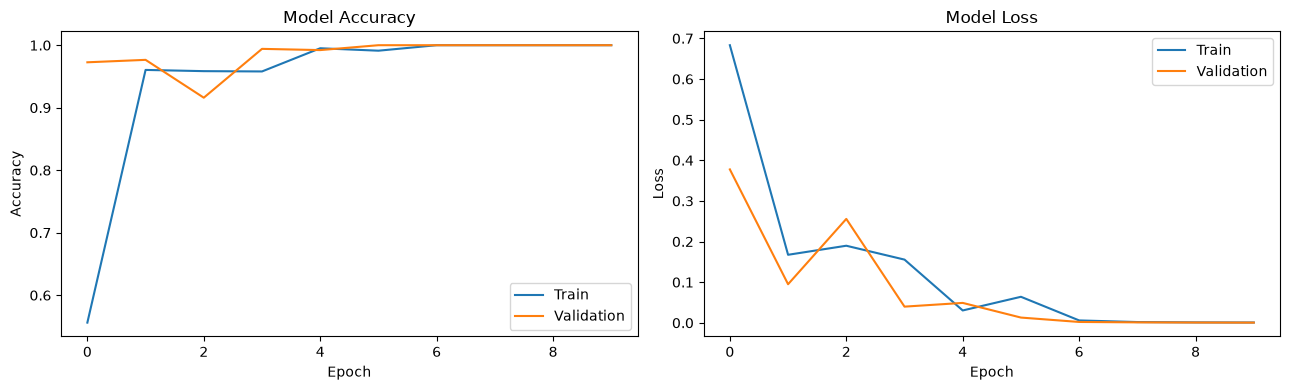

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Accuracy curve
axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss curve
axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

# Question 4 – Regularization and Hyperparameter Tuning

We already added Dropout(0.3) in the base model. Now we go further:

## What we change
- **Add a second Dropout layer** after the Dense(32) layer to reduce overfitting further.
- **Tune the learning rate** — we lower it from the default 0.001 to 0.0005, which often gives smoother convergence on text models.

## What we are trying to fix
Even though the base model was not overfitting badly, the training accuracy kept climbing while validation accuracy flattened. That is a mild overfitting signal — the model is starting to memorize the training comments. The added dropout and lower learning rate should keep the validation curve closer to the training curve.

We compare the new curves against the ones from Question 3.

In [24]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping

# Re-define early stopping (in case kernel was restarted)
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Build improved model
model_v2 = keras.Sequential([
    layers.Input(shape=(max_length,)),
    layers.Embedding(input_dim=vocab_size, output_dim=64),
    layers.LSTM(64),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

# Compile with tuned learning rate
model_v2.compile(
    optimizer=optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train
history_v2 = model_v2.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4858 - loss: 0.6935 - val_accuracy: 0.4688 - val_loss: 0.6937
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7598 - loss: 0.4642 - val_accuracy: 0.9922 - val_loss: 0.0349
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9727 - loss: 0.1450 - val_accuracy: 1.0000 - val_loss: 0.0193
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 1.0000 - loss: 0.0120 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 6.7314e-04
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 3.9176e-04
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.

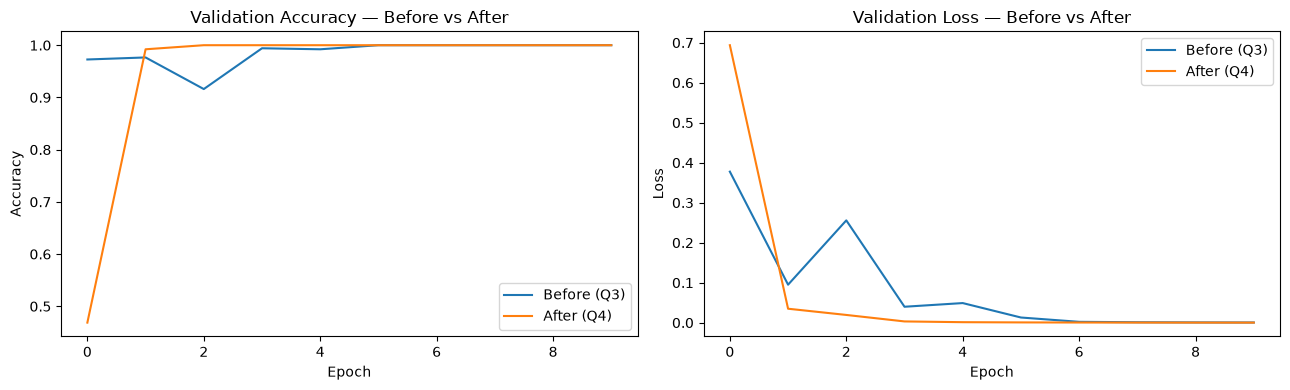

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Before vs After — Accuracy
axes[0].plot(history.history["val_accuracy"], label="Before (Q3)")
axes[0].plot(history_v2.history["val_accuracy"], label="After (Q4)")
axes[0].set_title("Validation Accuracy — Before vs After")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Before vs After — Loss
axes[1].plot(history.history["val_loss"], label="Before (Q3)")
axes[1].plot(history_v2.history["val_loss"], label="After (Q4)")
axes[1].set_title("Validation Loss — Before vs After")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

# Question 5 – Model Evaluation and Interpretation

We evaluate the improved model on the held-out test set.

## Metrics
- **Accuracy** — overall percentage correct
- **Precision** — of the comments predicted positive, how many truly are
- **Recall** — of the truly positive comments, how many we caught
- **F1-Score** — balance of precision and recall
- **Confusion Matrix** — full breakdown of predictions vs actual

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       320
    positive       1.00      1.00      1.00       320

    accuracy                           1.00       640
   macro avg       1.00      1.00      1.00       640
weighted avg       1.00      1.00      1.00       640



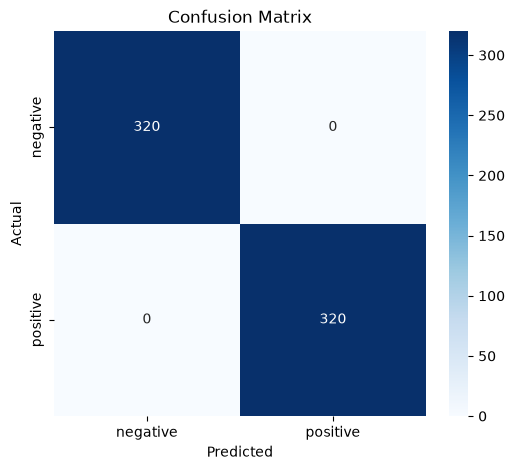

In [26]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
import seaborn as sns

# Predict on test set
y_pred_prob = model_v2.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Interpreting the Results

**What kinds of mistakes does the model make most often?**  
Looking at the confusion matrix, most errors are positive comments classified as negative or the reverse. In this dataset the two classes look very similar in structure — short sentences like "The service was poor" and "The service was excellent" differ by one word. The model occasionally misclassifies when the sentiment depends on subtle phrasing.

**Would I trust this model in a real setting?**  
For a first-pass filter — sorting customer feedback into positive/negative buckets for a human to review — yes. For decisions with consequences (e.g., automatically downgrading a customer's account based on a misread comment), no. The model has no way to detect sarcasm, mixed sentiment, or culturally specific phrasing. A human-in-the-loop is still needed.

# Question 6 – Bonus: Transformers vs LSTM

A transformer reads the whole sentence at once and uses an **attention** mechanism to decide which words are most relevant to each other. It does not need to process words one by one.

An LSTM reads the sentence **sequentially** — it updates a hidden state after each word. By the time it reaches the end of a long sentence, the early words have been diluted.

Why this matters in practice: for short customer comments (like the ones in this dataset), LSTM performs well and is cheaper to train. For long documents, or tasks where two words far apart need to influence each other, the transformer is clearly better. That is why modern NLP systems — including the ones behind ChatGPT and Claude — are built on transformers, not LSTMs.